# NeuralGCM Forecast Reliability — Environment Setup & First Inference

This notebook sets up the Colab environment and reproduces a basic NeuralGCM inference to verify everything works.

**Runtime**: Go to `Runtime > Change runtime type` and select **T4 GPU** (Colab Pro).

## 1. Install Dependencies

Colab comes with JAX pre-installed (with GPU support). We just need to install
neuralgcm and its dependencies on top. The `!pip install` commands run in the
Colab VM's Python environment — there's no need for conda or virtualenvs.

In [1]:
# Install neuralgcm and dependencies (~2-3 min on first run)
# neuralgcm pulls in: dinosaur (dynamical core), dm-haiku, gin-config, optax
# gcsfs is needed to load checkpoints and ERA5 data from Google Cloud Storage
!pip install -q neuralgcm dinosaur gcsfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.0/175.0 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.8/306.8 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 135.1 MB/s eta 0:00:00


In [2]:
# Verify GPU is available and JAX can see it
import jax
print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")
assert any(d.platform == 'gpu' for d in jax.devices()), (
    "No GPU found! Go to Runtime > Change runtime type > A100 GPU"
)

JAX version: 0.7.2
Devices: [CudaDevice(id=0)]


## 2. Imports

In [3]:
import gcsfs
import jax
import numpy as np
import pickle
import xarray

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

print(f"neuralgcm version: {neuralgcm.__version__}")

neuralgcm version: 1.2.2


## 3. Load Pretrained Model

Start with the 2.8° deterministic model for fast prototyping (~2.5s per 10-day forecast).
Switch to `stochastic_1_4_deg` for the real experiments.

In [4]:
model_name = 'v1/deterministic_2_8_deg.pkl'  # fast; switch to 'v1/stochastic_1_4_deg.pkl' later

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
    ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
print(f"Model loaded: {model_name}")
print(f"Input variables: {model.input_variables}")
print(f"Forcing variables: {model.forcing_variables}")

Model loaded: v1/deterministic_2_8_deg.pkl
Input variables: ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']
Forcing variables: ['sea_ice_cover', 'sea_surface_temperature']


## 4. Load ERA5 Data

ERA5 reanalysis is hosted on Google Cloud Storage in Zarr format. We load a
small time slice and regrid to the model's native resolution.

In [5]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)

# Select a short demo period (4 days from the 2020 holdout year)
demo_start_time = '2020-02-14'
demo_end_time = '2020-02-18'
data_inner_steps = 24  # sample every 24 hours

sliced_era5 = (
    full_era5
    [model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)
print(f"ERA5 slice loaded: {dict(sliced_era5.sizes)}")

ERA5 slice loaded: {'time': 5, 'level': 37, 'latitude': 721, 'longitude': 1440}


In [6]:
# Regrid ERA5 (0.25°) to model's native resolution
era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)
eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)
print(f"Regridded to model resolution: {dict(eval_era5.sizes)}")

Regridded to model resolution: {'level': 37, 'time': 5, 'longitude': 128, 'latitude': 64}


## 5. Run Inference (4-day forecast)

In [7]:
import time

inner_steps = 24   # save outputs every 24 hours
outer_steps = 4    # 4 days total
timedelta = np.timedelta64(1, 'h') * inner_steps
times = np.arange(outer_steps) * inner_steps  # time axis in hours

# Initialize model state from first ERA5 timestep
inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
rng_key = jax.random.key(42)
initial_state = model.encode(inputs, input_forcings, rng_key)

# Use persistence forcing (constant SST and sea ice)
all_forcings = model.forcings_from_xarray(eval_era5.head(time=1))

# Run forecast and time it
t0 = time.time()
final_state, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)
predictions_ds = model.data_to_xarray(predictions, times=times)
elapsed = time.time() - t0
print(f"Forecast complete: {outer_steps} days in {elapsed:.1f}s")
print(f"Prediction variables: {list(predictions_ds.data_vars)}")

Forecast complete: 4 days in 41.3s
Prediction variables: ['specific_humidity', 'geopotential', 'specific_cloud_ice_water_content', 'v_component_of_wind', 'sim_time', 'u_component_of_wind', 'temperature', 'specific_cloud_liquid_water_content']


## 6. Compare Forecast vs ERA5 (Sanity Check)

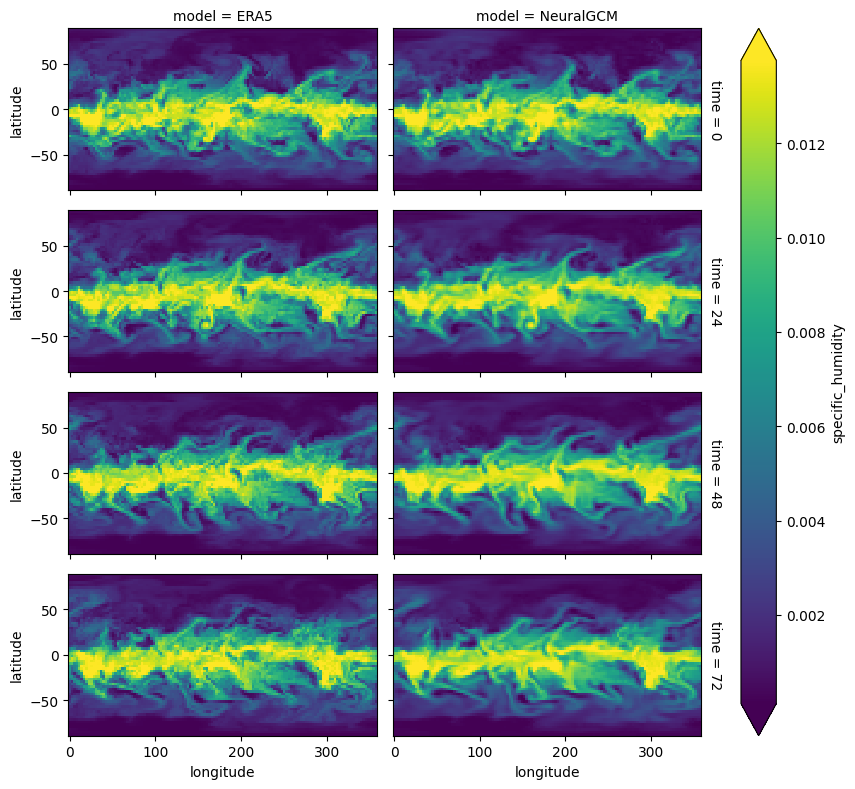

In [8]:
# Build ERA5 target trajectory for comparison
target_trajectory = model.inputs_from_xarray(
    eval_era5
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_ds = model.data_to_xarray(target_trajectory, times=times)

# Combine for side-by-side plotting
combined_ds = xarray.concat([target_ds, predictions_ds], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

# Plot specific humidity at 850 hPa
combined_ds.specific_humidity.sel(level=850).plot(
    x='longitude', y='latitude', row='time', col='model',
    robust=True, aspect=2, size=2
);

In [9]:
# Quick RMSE sanity check
import numpy as np

for var in ['temperature', 'geopotential', 'specific_humidity']:
    if var in predictions_ds and var in target_ds:
        diff = predictions_ds[var] - target_ds[var]
        # Area-weighted RMSE at final timestep
        weights = np.cos(np.deg2rad(predictions_ds.latitude))
        rmse = float(np.sqrt((diff.isel(time=-1) ** 2).weighted(weights).mean()).values)
        print(f"{var} RMSE (day {outer_steps}): {rmse:.4f}")

temperature RMSE (day 4): 2.5814
geopotential RMSE (day 4): 6977.9995
specific_humidity RMSE (day 4): 0.0005


---

## 7. Stochastic Ensemble Inference (NeuralGCM-ENS 1.4°)

The stochastic model generates different ensemble members by injecting noise
during `encode()`. Each unique `rng_key` produces a distinct member.

The Nature paper uses 50-member ensembles. We start with a small ensemble
(N=4) for prototyping, then scale up.

In [10]:
# Load the stochastic 1.4° model
stoch_model_name = 'v1/stochastic_1_4_deg.pkl'

with gcs.open(f'gs://neuralgcm/models/{stoch_model_name}', 'rb') as f:
    stoch_ckpt = pickle.load(f)

stoch_model = neuralgcm.PressureLevelModel.from_checkpoint(stoch_ckpt)
print(f"Stochastic model loaded: {stoch_model_name}")
print(f"Model resolution: {stoch_model.data_coords}")
print(f"Timestep: {stoch_model.timestep}")

Stochastic model loaded: v1/stochastic_1_4_deg.pkl
Model resolution: CoordinateSystem(horizontal=Grid(longitude_wavenumbers=128, total_wavenumbers=129, longitude_nodes=256, latitude_nodes=128, latitude_spacing='gauss', longitude_offset=0.0, radius=1.0, spherical_harmonics_impl=<class 'dinosaur.spherical_harmonic.RealSphericalHarmonicsWithZeroImag'>, spmd_mesh=None), vertical=PressureCoordinates(centers=array([   1,    2,    3,    5,    7,   10,   20,   30,   50,   70,  100,
        125,  150,  175,  200,  225,  250,  300,  350,  400,  450,  500,
        550,  600,  650,  700,  750,  775,  800,  825,  850,  875,  900,
        925,  950,  975, 1000])), spmd_mesh=None, dycore_partition_spec=PartitionSpec('z', 'x', 'y'), physics_partition_spec=PartitionSpec(None, ('x', 'z'), 'y'))
Timestep: 3600 seconds


In [11]:
# Re-slice ERA5 with the stochastic model's variables, then regrid to 1.4°
stoch_sliced_era5 = (
    full_era5
    [stoch_model.input_variables + stoch_model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=stoch_model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

stoch_regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, stoch_model.data_coords.horizontal, skipna=True
)
stoch_era5 = xarray_utils.regrid(stoch_sliced_era5, stoch_regridder)
stoch_era5 = xarray_utils.fill_nan_with_nearest(stoch_era5)
print(f"Regridded to 1.4°: {dict(stoch_era5.sizes)}")
print(f"Variables: {list(stoch_era5.data_vars)}")

Regridded to 1.4°: {'level': 37, 'time': 5, 'longitude': 256, 'latitude': 128}
Variables: ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content', 'sea_ice_cover', 'sea_surface_temperature']


### Run ensemble forecast

Each member gets a different `rng_key` passed to `encode()`, which injects
different noise into the learned encoder and physics module. The `unroll` call
itself is deterministic given the initial state.

In [12]:
n_ensemble = 4  # start small; scale to 50 for real experiments
inner_steps = 24
outer_steps = 4
timedelta = np.timedelta64(1, 'h') * inner_steps
times = np.arange(outer_steps) * inner_steps

stoch_inputs = stoch_model.inputs_from_xarray(stoch_era5.isel(time=0))
stoch_input_forcings = stoch_model.forcings_from_xarray(stoch_era5.isel(time=0))
stoch_all_forcings = stoch_model.forcings_from_xarray(stoch_era5.head(time=1))

ensemble_predictions = []
t0 = time.time()

for member in range(n_ensemble):
    rng_key = jax.random.key(member)
    state = stoch_model.encode(stoch_inputs, stoch_input_forcings, rng_key)
    _, preds = stoch_model.unroll(
        state, stoch_all_forcings,
        steps=outer_steps, timedelta=timedelta, start_with_input=True,
    )
    pred_ds = stoch_model.data_to_xarray(preds, times=times)
    ensemble_predictions.append(pred_ds)
    print(f"  Member {member} done")

elapsed = time.time() - t0
print(f"\nEnsemble ({n_ensemble} members, {outer_steps} days) in {elapsed:.1f}s")
print(f"Per member: {elapsed/n_ensemble:.1f}s")

  Member 0 done
  Member 1 done
  Member 2 done
  Member 3 done

Ensemble (4 members, 4 days) in 560.1s
Per member: 140.0s


In [13]:
# Stack ensemble into a single dataset with an 'ensemble' dimension
ensemble_ds = xarray.concat(ensemble_predictions, dim='member')
ensemble_ds.coords['member'] = np.arange(n_ensemble)
print(f"Ensemble dataset: {dict(ensemble_ds.sizes)}")

Ensemble dataset: {'member': 4, 'time': 4, 'level': 37, 'longitude': 256, 'latitude': 128}


### Ensemble statistics: mean, spread, spread-skill ratio

In [14]:
# Build ERA5 target at 1.4° resolution for comparison
stoch_target = stoch_model.inputs_from_xarray(
    stoch_era5
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_ds_14 = stoch_model.data_to_xarray(stoch_target, times=times)

# Ensemble mean and spread (std across members)
ens_mean = ensemble_ds.mean(dim='member')
ens_spread = ensemble_ds.std(dim='member')

# Area weights
weights = np.cos(np.deg2rad(ensemble_ds.latitude))

# Evaluate at standard pressure levels (matching WeatherBench2 / Nature paper)
eval_levels = [
    ('geopotential', 500),
    ('temperature', 850),
    ('specific_humidity', 700),
    ('u_component_of_wind', 700),
]

print("Variable                | RMSE (ens mean) | Spread (mean) | Spread/Skill")
print("-" * 75)
for var, level in eval_levels:
    if var not in ens_mean:
        continue
    error = ens_mean[var].sel(level=level).isel(time=-1) - target_ds_14[var].sel(level=level).isel(time=-1)
    rmse = float(np.sqrt((error ** 2).weighted(weights).mean()).values)
    spread = float(ens_spread[var].sel(level=level).isel(time=-1).weighted(weights).mean().values)
    ratio = spread / rmse if rmse > 0 else float('nan')
    print(f"{var + ' ' + str(level) + 'hPa':<24} | {rmse:>14.4f}  | {spread:>12.4f}  | {ratio:.3f}")

Variable                | RMSE (ens mean) | Spread (mean) | Spread/Skill
---------------------------------------------------------------------------
geopotential 500hPa      |       121.6013  |      94.9352  | 0.781
temperature 850hPa       |         1.0747  |       0.7671  | 0.714
specific_humidity 700hPa |         0.0009  |       0.0005  | 0.615
u_component_of_wind 700hPa |         2.4158  |       1.6874  | 0.698


### Visualize ensemble spread

Plot ensemble members overlaid to see the spread growing with lead time.

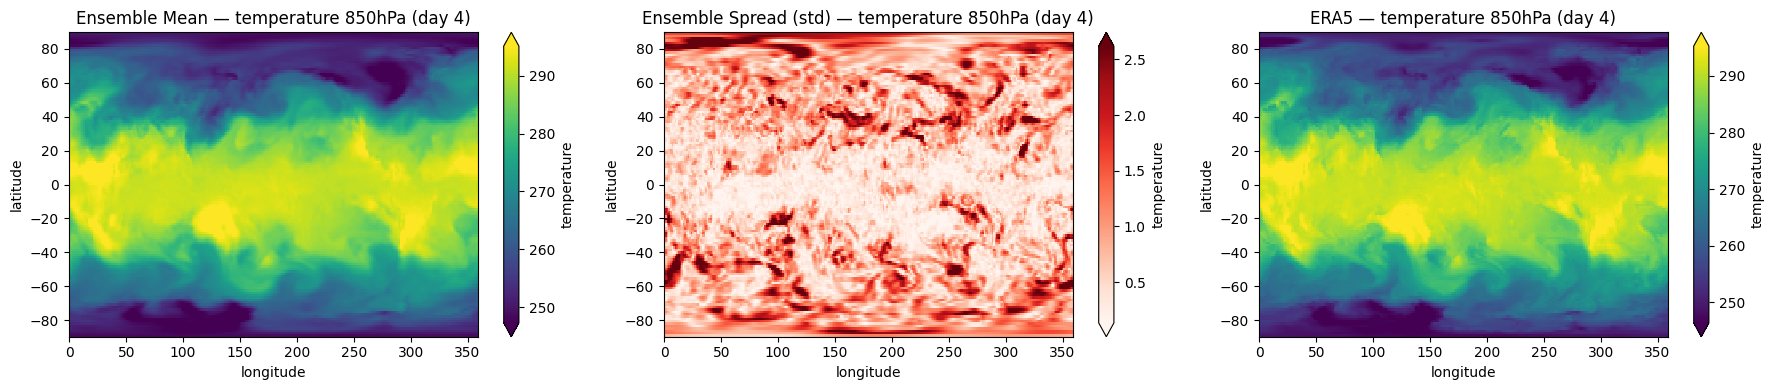

In [15]:
import matplotlib.pyplot as plt

var = 'temperature'
level = 850
day = -1  # final timestep

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: Ensemble mean
ens_mean[var].sel(level=level).isel(time=day).plot(
    ax=axes[0], x='longitude', y='latitude', robust=True
)
axes[0].set_title(f'Ensemble Mean — {var} {level}hPa (day {outer_steps})')

# Panel 2: Ensemble spread (std)
ens_spread[var].sel(level=level).isel(time=day).plot(
    ax=axes[1], x='longitude', y='latitude', robust=True, cmap='Reds'
)
axes[1].set_title(f'Ensemble Spread (std) — {var} {level}hPa (day {outer_steps})')

# Panel 3: ERA5 truth
target_ds_14[var].sel(level=level).isel(time=day).plot(
    ax=axes[2], x='longitude', y='latitude', robust=True
)
axes[2].set_title(f'ERA5 — {var} {level}hPa (day {outer_steps})')

plt.tight_layout()
plt.show()

### Spread growth over lead time

The spread should grow with forecast lead time as uncertainty increases.
A well-calibrated ensemble has spread/skill ~ 1.0 at all lead times.

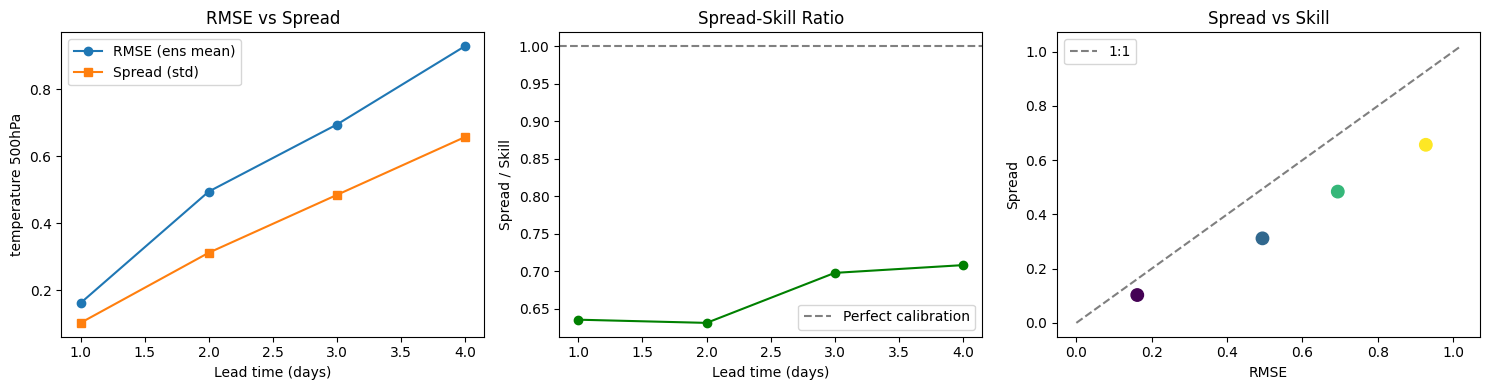


Note: with only 4 members, spread estimates are noisy.
Scale to 50 members for reliable statistics.


In [16]:
var = 'temperature'
level = 500

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rmse_by_time = []
spread_by_time = []
for t in range(outer_steps):
    error = ens_mean[var].sel(level=level).isel(time=t) - target_ds_14[var].sel(level=level).isel(time=t)
    rmse_t = float(np.sqrt((error ** 2).weighted(weights).mean()).values)
    spread_t = float(ens_spread[var].sel(level=level).isel(time=t).weighted(weights).mean().values)
    rmse_by_time.append(rmse_t)
    spread_by_time.append(spread_t)

days = np.arange(1, outer_steps + 1)

axes[0].plot(days, rmse_by_time, 'o-', label='RMSE (ens mean)')
axes[0].plot(days, spread_by_time, 's-', label='Spread (std)')
axes[0].set_xlabel('Lead time (days)')
axes[0].set_ylabel(f'{var} {level}hPa')
axes[0].legend()
axes[0].set_title('RMSE vs Spread')

ratio = [s / r if r > 0 else float('nan') for s, r in zip(spread_by_time, rmse_by_time)]
axes[1].plot(days, ratio, 'o-', color='green')
axes[1].axhline(1.0, color='gray', linestyle='--', label='Perfect calibration')
axes[1].set_xlabel('Lead time (days)')
axes[1].set_ylabel('Spread / Skill')
axes[1].legend()
axes[1].set_title('Spread-Skill Ratio')

# Panel 3: spread vs RMSE scatter
axes[2].scatter(rmse_by_time, spread_by_time, c=days, cmap='viridis', s=80, zorder=3)
max_val = max(max(rmse_by_time), max(spread_by_time)) * 1.1
axes[2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='1:1')
axes[2].set_xlabel('RMSE')
axes[2].set_ylabel('Spread')
axes[2].legend()
axes[2].set_title('Spread vs Skill')

plt.tight_layout()
plt.show()

print(f"\nNote: with only {n_ensemble} members, spread estimates are noisy.")
print("Scale to 50 members for reliable statistics.")

---

## 8. Extended Forecast (10 days, 50-member ensemble)

Scale up to publication-quality ensemble size and forecast length.
Need more ERA5 data to cover the longer verification window.

In [17]:
# Load a longer ERA5 window (10+ days for verification)
ext_start = '2020-02-14'
ext_end = '2020-02-25'  # 11 days to cover init + 10-day forecast

ext_sliced = (
    full_era5
    [stoch_model.input_variables + stoch_model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=stoch_model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(ext_start, ext_end, data_inner_steps))
    .compute()
)

ext_era5 = xarray_utils.regrid(ext_sliced, stoch_regridder)
ext_era5 = xarray_utils.fill_nan_with_nearest(ext_era5)
print(f"Extended ERA5: {dict(ext_era5.sizes)}")

Extended ERA5: {'level': 37, 'time': 12, 'longitude': 256, 'latitude': 128}


In [18]:
n_members = 50
ext_outer_steps = 10  # 10-day forecast
ext_timedelta = np.timedelta64(1, 'h') * inner_steps
ext_times = np.arange(ext_outer_steps) * inner_steps

ext_inputs = stoch_model.inputs_from_xarray(ext_era5.isel(time=0))
ext_input_forcings = stoch_model.forcings_from_xarray(ext_era5.isel(time=0))
ext_all_forcings = stoch_model.forcings_from_xarray(ext_era5.head(time=1))

# Incremental mean and variance (Welford's algorithm) to avoid OOM
# Only keep running stats, not all 50 member arrays
ens_sum = None
ens_sum_sq = None
t0 = time.time()

for member in range(n_members):
    rng_key = jax.random.key(member)
    state = stoch_model.encode(ext_inputs, ext_input_forcings, rng_key)
    _, preds = stoch_model.unroll(
        state, ext_all_forcings,
        steps=ext_outer_steps, timedelta=ext_timedelta, start_with_input=True,
    )
    pred_ds = stoch_model.data_to_xarray(preds, times=ext_times)

    if ens_sum is None:
        ens_sum = pred_ds.copy(deep=True)
        ens_sum_sq = pred_ds ** 2
    else:
        ens_sum = ens_sum + pred_ds
        ens_sum_sq = ens_sum_sq + pred_ds ** 2

    del preds, pred_ds, state  # free memory
    if (member + 1) % 10 == 0:
        elapsed = time.time() - t0
        print(f"  {member + 1}/{n_members} members done ({elapsed:.0f}s)")

elapsed = time.time() - t0
print(f"\nDone: {n_members} members, {ext_outer_steps} days in {elapsed:.0f}s")
print(f"Per member: {elapsed/n_members:.1f}s")

  10/50 members done (3143s)
  20/50 members done (6252s)
  30/50 members done (9362s)
  40/50 members done (12457s)
  50/50 members done (15563s)

Done: 50 members, 10 days in 15563s
Per member: 311.3s


In [21]:
# Compute mean and std from running sums
ext_ens_mean = ens_sum / n_members
ext_ens_variance = (ens_sum_sq / n_members) - (ext_ens_mean ** 2)
ext_ens_spread = ext_ens_variance.clip(min=0) ** 0.5  # avoid sqrt of tiny negatives

ext_target = stoch_model.inputs_from_xarray(
    ext_era5
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(ext_outer_steps))
)
ext_target_ds = stoch_model.data_to_xarray(ext_target, times=ext_times)

print("Ensemble stats computed (mean + spread) without storing all members")

Ensemble stats computed (mean + spread) without storing all members


### Spread-skill curves over 10 days

These should match the shape of Nature paper Fig. 2g — spread/skill ratio
starting near 1.0 and staying roughly constant across lead times for a
well-calibrated ensemble.

In [ ]:
eval_levels = [
    ('geopotential', 500, 'Z500 [m²/s²]'),
    ('temperature', 850, 'T850 [K]'),
    ('specific_humidity', 700, 'Q700 [kg/kg]'),
    ('u_component_of_wind', 700, 'U700 [m/s]'),
]

weights = np.cos(np.deg2rad(ext_ens_mean.latitude))
days = np.arange(1, ext_outer_steps + 1)

fig, axes = plt.subplots(2, len(eval_levels), figsize=(5 * len(eval_levels), 8))

for col, (var, level, label) in enumerate(eval_levels):
    rmse_curve = []
    spread_curve = []
    for t in range(ext_outer_steps):
        error = ext_ens_mean[var].sel(level=level).isel(time=t) - ext_target_ds[var].sel(level=level).isel(time=t)
        rmse_t = float(np.sqrt((error ** 2).weighted(weights).mean()).values)
        spread_t = float(ext_ens_spread[var].sel(level=level).isel(time=t).weighted(weights).mean().values)
        rmse_curve.append(rmse_t)
        spread_curve.append(spread_t)

    axes[0, col].plot(days, rmse_curve, 'o-', label='RMSE', color='tab:blue')
    axes[0, col].plot(days, spread_curve, 's-', label='Spread', color='tab:orange')
    axes[0, col].set_xlabel('Lead time (days)')
    axes[0, col].set_ylabel(label)
    axes[0, col].set_title(label)
    axes[0, col].legend(fontsize=8)

    ratio_curve = [s / r if r > 0 else float('nan') for s, r in zip(spread_curve, rmse_curve)]
    axes[1, col].plot(days, ratio_curve, 'o-', color='green')
    axes[1, col].axhline(1.0, color='gray', linestyle='--', alpha=0.7)
    axes[1, col].set_xlabel('Lead time (days)')
    axes[1, col].set_ylabel('Spread / Skill')
    axes[1, col].set_ylim(0, 2)
    axes[1, col].set_title(f'{label} — Spread/Skill')

plt.tight_layout()
plt.show()

### Summary table by lead time

In [24]:
# Print spread/skill ratio at key lead times for all variables
print(f"{'Variable':<28} | {'Day 1':>8} | {'Day 3':>8} | {'Day 5':>8} | {'Day 7':>8} | {'Day 10':>8}")
print("-" * 85)
for var, level, label in eval_levels:
    ratios = []
    for t in range(ext_outer_steps):
        error = ext_ens_mean[var].sel(level=level).isel(time=t) - ext_target_ds[var].sel(level=level).isel(time=t)
        rmse_t = float(np.sqrt((error ** 2).weighted(weights).mean()).values)
        spread_t = float(ext_ens_spread[var].sel(level=level).isel(time=t).weighted(weights).mean().values)
        ratios.append(spread_t / rmse_t if rmse_t > 0 else float('nan'))
    row = f"{label:<28}"
    for d in [0, 2, 4, 6, 9]:  # day 1, 3, 5, 7, 10
        row += f" | {ratios[d]:>8.3f}"
    print(row)

Variable                     |    Day 1 |    Day 3 |    Day 5 |    Day 7 |   Day 10
-------------------------------------------------------------------------------------
Z500 [m²/s²]                 |    0.567 |    1.056 |    0.954 |    0.836 |    0.783
T850 [K]                     |    0.651 |    0.891 |    0.928 |    0.855 |    0.872
Q700 [kg/kg]                 |    0.573 |    0.776 |    0.831 |    0.876 |    0.888
U700 [m/s]                   |    0.709 |    0.923 |    0.960 |    0.988 |    0.890


## Next Steps

1. **Multiple init times**: Loop over ~20-50 init dates from 2020 to get robust statistics
2. **CRPS implementation**: Proper probabilistic scoring (Week 2-3)
3. **Regional decomposition**: Tropics vs extratropics, land vs ocean spread-skill maps
4. **Distribution shift analysis**: Compare in-distribution vs held-out year calibration (Week 4)